In [243]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor

In [244]:
data = pd.read_csv('ecommerce_furniture_dataset_2024.csv')
print(data.head())

                                        productTitle originalPrice    price  \
0  Dresser For Bedroom With 9 Fabric Drawers Ward...           NaN   $46.79   
1  Outdoor Conversation Set 4 Pieces Patio Furnit...           NaN  $169.72   
2  Desser For Bedroom With 7 Fabric Drawers Organ...         $78.4   $39.46   
3  Modern Accent Boucle Chair,Upholstered Tufted ...           NaN  $111.99   
4  Small Unit Simple Computer Desk Household Wood...        $48.82   $21.37   

   sold        tagText  
0   600  Free shipping  
1     0  Free shipping  
2     7  Free shipping  
3     0  Free shipping  
4     1  Free shipping  


In [245]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   productTitle   2000 non-null   object
 1   originalPrice  487 non-null    object
 2   price          2000 non-null   object
 3   sold           2000 non-null   int64 
 4   tagText        1997 non-null   object
dtypes: int64(1), object(4)
memory usage: 78.3+ KB
None


In [246]:
data.describe()


,sold
count,2000.000000
mean,23.493500
std,254.094061
min,0.000000
25%,1.000000
50%,3.000000
75%,9.000000
max,10000.000000


In [247]:
data.duplicated().sum()

94

In [248]:
df = data[data.duplicated()]

In [249]:
df

,productTitle,originalPrice,price,sold,tagText
65,6Pieces Wicker Patio Furniture Sets Outdoor Co...,NaN,$574.86,0,Free shipping
70,"3 PCS Patio Conversation Set, Solid Eucalyptus...",NaN,$117.66,0,Free shipping
76,7 Pieces Patio Furniture Set - Outdoor Section...,NaN,$376.5,0,Free shipping
77,5 Pieces Patio Furniture Set Outdoor Sectional...,NaN,$219.63,0,Free shipping
78,"Aluminum Patio Furniture Set, Modern Patio Con...",NaN,$497.44,1,Free shipping
...,...,...,...,...,...
1986,"104"" Linen Fabric Sofa with Armrest Pockets an...",NaN,$308.16,7,Free shipping
1988,2023 New 3 Drawer Sliding Barrel Modern Bedroo...,NaN,$37.09,10,Free shipping
1995,Modern TV Stand Entertainment Center with Two ...,NaN,$72.49,8,Free shipping
1996,"Large Wardrobe Armoire Closet with 3 Doors, Fr...",NaN,$276.65,2,Free shipping


In [250]:
df = df.drop_duplicates()

In [251]:
df.duplicated().sum()

0

In [252]:
df.isnull().sum()

productTitle      0
originalPrice    76
price             0
sold              0
tagText           1
dtype: int64

In [253]:
df.sample(50)

,productTitle,originalPrice,price,sold,tagText
78,"Aluminum Patio Furniture Set, Modern Patio Con...",NaN,$497.44,1,Free shipping
1963,Portable Wardrobe Closet Storage Organizer Lar...,NaN,$214.69,0,Free shipping
1918,"LED TV Stand for TV Up to 75"" Entertainment Ce...",NaN,$166.58,1,Free shipping
1876,Modern Ottoman Velvet Footstool Bench for Bedr...,NaN,$63.98,2,Free shipping
1881,"Queen Size Bed Frame,Metal Platform 14 Inch Be...",NaN,$75.22,3,Free shipping
156,Outdoor Furniture Sets Sectional PE Rattan Out...,$736.43,$435.86,5,Free shipping
1852,LEEGOHOME Wardrobes Closet armario Cloth Bedro...,NaN,$23.37,10,Free shipping
1887,2 Door Wood Wardrobe Bedroom Closet with Cloth...,NaN,$208.32,7,Free shipping
1916,"Floating Bed Frame Queen Size with LED Lights,...",NaN,$101.53,4,Free shipping
545,"Courtyard patio furniture set, 4-piece outdoor...",NaN,$501.86,0,Free shipping


In [254]:
df = data[data.duplicated()].copy()


In [255]:
df['price'] = df['price'].astype(str).replace(r'[\$,]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['originalPrice'] = df['originalPrice'].astype(str).replace(r'[\$,]', '', regex=True)
df['originalPrice'] = pd.to_numeric(df['originalPrice'], errors='coerce')

In [256]:
median_originalPrice = df['originalPrice'].median(skipna = True)

In [257]:
pd.set_option('future.no_silent_downcasting', True)
df['originalPrice'] = df['originalPrice'].fillna(median_originalPrice).infer_objects(copy=False)

In [258]:
df.sample(50)

,productTitle,originalPrice,price,sold,tagText
1887,2 Door Wood Wardrobe Bedroom Closet with Cloth...,236.96,208.32,7,Free shipping
76,7 Pieces Patio Furniture Set - Outdoor Section...,236.96,376.50,0,Free shipping
1876,Modern Ottoman Velvet Footstool Bench for Bedr...,236.96,63.98,2,Free shipping
1918,"LED TV Stand for TV Up to 75"" Entertainment Ce...",236.96,166.58,1,Free shipping
1888,"Flower Shape Velvet Armchair, Modern Side Chai...",236.96,71.42,4,Free shipping
1869,"Yaheetech Sherpa Fabric Accent Chair, Modern C...",236.96,101.44,0,Free shipping
1975,No Box Spring Needed Platform Bed Bases & Fram...,236.96,396.07,14,Free shipping
1884,Modern Rectangle Wood Coffee Table with Storag...,236.96,58.94,0,Free shipping
1930,"Makeup Vanity Desk with HD Lighted Mirror, Mir...",236.96,262.21,2,Free shipping
1856,Cloud Living Room Coffee Table High Gloss Stor...,236.96,167.02,2,+Shipping: $97.54


In [259]:
df['tagText'].value_counts()

tagText
Free shipping        91
+Shipping: $97.54     1
+Shipping: $34.63     1
Name: count, dtype: int64

In [260]:
import re
import numpy as np

def extract_shipping_cost(text):
    if isinstance(text, str):
        text = text.strip()
        if 'Free' in text:
            return 0.0
        match = re.search(r'\$([\d\.]+)', text)
        if match:
            return float(match.group(1))
    return np.nan 


In [261]:
df['shipping_cost'] = df['tagText'].apply(extract_shipping_cost)

In [262]:
df['shipping_cost'] = df['shipping_cost'].fillna(df['shipping_cost'].median())

In [263]:
df['free_shipping'] = (df['shipping_cost'] == 0).astype(int)

In [264]:
print(df.head())

                                         productTitle  originalPrice   price  \
65  6Pieces Wicker Patio Furniture Sets Outdoor Co...         236.96  574.86   
70  3 PCS Patio Conversation Set, Solid Eucalyptus...         236.96  117.66   
76  7 Pieces Patio Furniture Set - Outdoor Section...         236.96  376.50   
77  5 Pieces Patio Furniture Set Outdoor Sectional...         236.96  219.63   
78  Aluminum Patio Furniture Set, Modern Patio Con...         236.96  497.44   

    sold        tagText  shipping_cost  free_shipping  
65     0  Free shipping            0.0              1  
70     0  Free shipping            0.0              1  
76     0  Free shipping            0.0              1  
77     0  Free shipping            0.0              1  
78     1  Free shipping            0.0              1  


In [265]:
df['Discount'] = ((df['originalPrice']-df['price'])/df['originalPrice']).clip(lower = 0)

In [266]:
print(df.head())

                                         productTitle  originalPrice   price  \
65  6Pieces Wicker Patio Furniture Sets Outdoor Co...         236.96  574.86   
70  3 PCS Patio Conversation Set, Solid Eucalyptus...         236.96  117.66   
76  7 Pieces Patio Furniture Set - Outdoor Section...         236.96  376.50   
77  5 Pieces Patio Furniture Set Outdoor Sectional...         236.96  219.63   
78  Aluminum Patio Furniture Set, Modern Patio Con...         236.96  497.44   

    sold        tagText  shipping_cost  free_shipping  Discount  
65     0  Free shipping            0.0              1  0.000000  
70     0  Free shipping            0.0              1  0.503460  
76     0  Free shipping            0.0              1  0.000000  
77     0  Free shipping            0.0              1  0.073135  
78     1  Free shipping            0.0              1  0.000000  


In [267]:
y = np.log1p(df['sold']) 
X = df.drop(columns=['sold'])

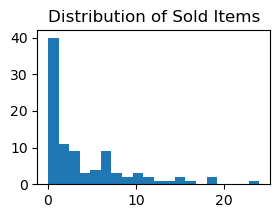

In [268]:
import matplotlib.pyplot as plt
plt.figure(figsize = (3,2))
plt.hist(df['sold'], bins=20)
plt.title('Distribution of Sold Items')
plt.show()


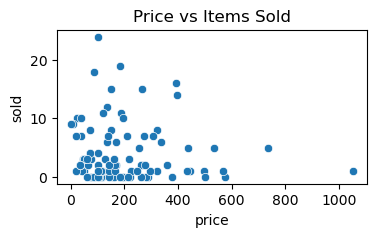

In [269]:
# price vs items sold
import seaborn as sns
plt.figure(figsize = (4,2))
sns.scatterplot(x='price', y='sold', data=df)
plt.title("Price vs Items Sold")
plt.show()

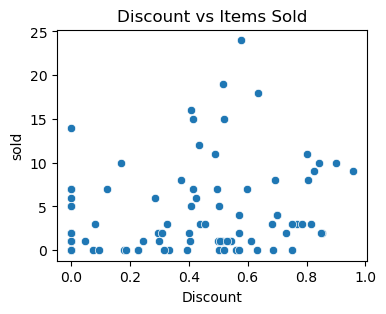

In [270]:
#Discount vs Item sold
plt.figure(figsize=(4,3))
sns.scatterplot(x='Discount', y='sold', data=df)
plt.title("Discount vs Items Sold")
plt.show()

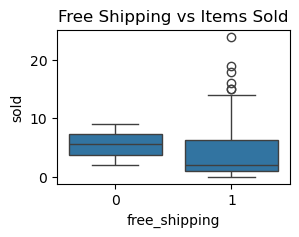

In [271]:
plt.figure(figsize=(3,2))
sns.boxplot(x='free_shipping', y='sold', data=df)
plt.title("Free Shipping vs Items Sold")
plt.show()

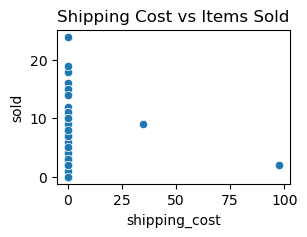

In [272]:
#Shipping cost vs Items sold
plt.figure(figsize=(3,2))
sns.scatterplot(x='shipping_cost', y='sold', data=df)
plt.title("Shipping Cost vs Items Sold")
plt.show()

In [273]:
df['productTitle'].value_counts()

productTitle
Patio Furniture Sets - 3 Pieces Rattan Sofa Set, Outdoor Conversation Set with Tempered Glass Tabletop, Outdoor Furniture Sets      2
3 Pieces Rocking Wicker Bistro Set, Patio Outdoor Furniture Conversation Sets with Porch Chairs and Glass Coffee Table, Beige       2
AMERLIFE Makeup Vanity Table Set with Sliding & LED Lighted Mirror, 45" Large Vanity with Charging Station, 4 Drawers               1
Makeup Vanity Desk with HD Lighted Mirror, Mirror and Lights, Dressing Table with Drawers & Shelves, Glass Top for Bedroom          1
Small Japanese Luxury Coffee Tables Unusual Entryways Modern Corner Coffee Table Cute Round Mesa De Centro Living Room Furniture    1
                                                                                                                                   ..
Makeup Vanity Desk Set Pearl-White 3 Color Lighting Modes Make Up Table Makeup Vanity With Large Lighted Mirror Furnitures Light    1
31.5in(L)… Home Furniture Luxury Cute Vanity Make

In [274]:
from sklearn.feature_extraction.text import TfidfVectorizer
numeric_features = ['price', 'originalPrice','Discount','shipping_cost','free_shipping']
text_feature = 'productTitle'

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('txt', TfidfVectorizer(
            max_features=800,
            ngram_range=(1,2),
            min_df = 3,
            stop_words='english'
        ), text_feature)
    ]
)


In [275]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [276]:
from xgboost import XGBRegressor
model = XGBRegressor(
    n_estimators=700,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42
)




In [277]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])


In [278]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['price', 'originalPrice',
                                                   'Discount', 'shipping_cost',
                                                   'free_shipping']),
                                                 ('txt',
                                                  TfidfVectorizer(max_features=800,
                                                                  min_df=3,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words='english'),
                                                  'productTitle')])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.03,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=7, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=700, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [279]:
!pip install xgboost
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

In [280]:
y_pred_log = pipeline.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

r2 = r2_score(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)

print("R² Score:", r2)
print("RMSE:", rmse)
print("MSE:" ,mse)


R² Score: 0.3276425819742059
RMSE: 2.7321865927159092
MSE: 7.464843577416571


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [281]:
#Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=3,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)


rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', rf_model)
])
rf_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['price', 'originalPrice',
                                                   'Discount', 'shipping_cost',
                                                   'free_shipping']),
                                                 ('txt',
                                                  TfidfVectorizer(max_features=800,
                                                                  min_df=3,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words='english'),
                                                  'productTitle')])),
                ('model',
                 RandomForestRegressor(max_depth=15, min_samples_leaf=3,
                                       min_samples_split=5, n_estimators=500,
                                       n_jobs=-1, random_state=42))])

In [282]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred_log = rf_pipeline.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)
r2 = r2_score(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)               
rmse = mean_squared_error(y_true, y_pred, squared=False)  

print("Random Forest R² Score:", r2)
print("Random Forest MSE:", mse)
print("Random Forest RMSE:", rmse)


Random Forest R² Score: 0.3468747489811007
Random Forest MSE: 7.2513185764092745
Random Forest RMSE: 2.692827245927461


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
